<a href="https://colab.research.google.com/github/marielaAriass/YeastMat/blob/main/identidad/heatmap_identidadXYZ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **heatmap_identidadXYZ**

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Diccionario actualizado de especie por cepa
cepa_especie = {
    'ADE': 'S. cerevisiae', 'ADI': 'S. cerevisiae', 'AHG': 'S. cerevisiae', 'AHL': 'S. cerevisiae',
    'AIE': 'S. cerevisiae', 'ALI': 'S. cerevisiae', 'AMH': 'S. cerevisiae', 'AVB': 'S. cerevisiae',
    'BBM': 'S. cerevisiae', 'BCE': 'S. cerevisiae', 'BCN': 'S. cerevisiae', 'CEI': 'S. cerevisiae',
    'CPA': 'S. cerevisiae', 'CPG': 'S. cerevisiae', 'CPI': 'S. cerevisiae', 'CQS': 'S. cerevisiae',
    'CBS432': 'S. paradoxus', 'N44': 'S. paradoxus', 'UWOPS91': 'S. paradoxus',
    'YPS138': 'S. paradoxus', 'UFRJ50816': 'S. paradoxus'
}

def obtener_especie(nombre):
    for prefix in cepa_especie:
        if nombre.startswith(prefix):
            return cepa_especie[prefix]
    return "Desconocida"

def obtener_matriz_ordenada(archivo_excel):
    hojas = pd.ExcelFile(archivo_excel).sheet_names
    for hoja in hojas:
        df = pd.read_excel(archivo_excel, sheet_name=hoja, index_col=0)
        df_numerico = df.select_dtypes(include=['number'])

        if df_numerico.empty:
            print(f'No hay datos numéricos en la hoja {hoja}.')
            continue

        correlation_matrix = df_numerico.corr()
        sorted_columns = correlation_matrix[correlation_matrix.columns[0]].sort_values(ascending=False).index
        df_ordenado = df_numerico[sorted_columns].loc[sorted_columns]

        return df_ordenado
    return None

def generar_color_labels(df):
    colores = []
    for label in df.columns:
        especie = obtener_especie(label)
        if especie == 'S. cerevisiae':
            colores.append('#FF7F0E')  # naranja fuerte
        elif especie == 'S. paradoxus':
            colores.append('#1F77B4')  # azul fuerte
        else:
            colores.append('gray')
    return colores

In [ ]:
def generar_subplot_heatmaps(archivo1, gen1, archivo2, gen2, archivo3, gen3, archivo4, gen4):
    os.makedirs('Images', exist_ok=True)

    # Cargar matrices
    df1 = obtener_matriz_ordenada(archivo1)
    df2 = obtener_matriz_ordenada(archivo2)
    df3 = obtener_matriz_ordenada(archivo3)
    df4 = obtener_matriz_ordenada(archivo4)

    if any(df is None for df in [df1, df2, df3, df4]):
        print("No se pudieron obtener matrices válidas.")
        return

    # Crear figura con 2 filas x 2 columnas
    fig, axes = plt.subplots(2, 2, figsize=(24, 20))
    cmap = sns.color_palette("coolwarm", as_cmap=True)

    # Lista de dataframes y genes
    dfs = [df1, df2, df3, df4]
    genes = [gen1, gen2, gen3, gen4]
    axes = axes.flatten()  # Para iterar fácilmente sobre los 4 subplots

    for df, gen, ax in zip(dfs, genes, axes):
        row_colors = generar_color_labels(df)
        col_colors = generar_color_labels(df)

        sns.heatmap(df, ax=ax, cmap=cmap, annot=False, fmt=".2f",
                    xticklabels=True, yticklabels=True, cbar=True)

        # Ajustar la barra de color
        cbar = ax.collections[0].colorbar
        cbar.ax.tick_params(labelsize=14)

        # Etiquetas
        ax.set_xticklabels(df.columns, rotation=45, ha='right', fontsize=10, fontweight='bold')
        ax.set_yticklabels(df.index, fontsize=10, fontweight='bold')
        ax.set_title(f'Identidad de gen {gen}', fontsize=18, fontweight='bold')

        # Colorear etiquetas
        for label, color in zip(ax.get_xticklabels(), col_colors):
            label.set_color(color)
        for label, color in zip(ax.get_yticklabels(), row_colors):
            label.set_color(color)


    # 🔹 Título principal de toda la figura
    fig.suptitle("Identidad entre secuencias de los genes X, Ya, Yα y Z de los loci HMR, MAT, HML",
                 fontsize=26, fontweight='bold')

    # Leyenda general (ahora la movemos un poco más abajo del título)
    handles = [
        plt.Line2D([0], [0], color='#FF7F0E', lw=6, label='S. cerevisiae'),
        plt.Line2D([0], [0], color='#1F77B4', lw=6, label='S. paradoxus')
    ]
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 0.96),
               ncol=2, fontsize=18, title="Especie", title_fontsize=16)

    # Ajuste de márgenes para que no se encimen
    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.savefig(f'Images/heatmaps_identidad.svg', dpi=500, bbox_inches="tight")

    plt.show()



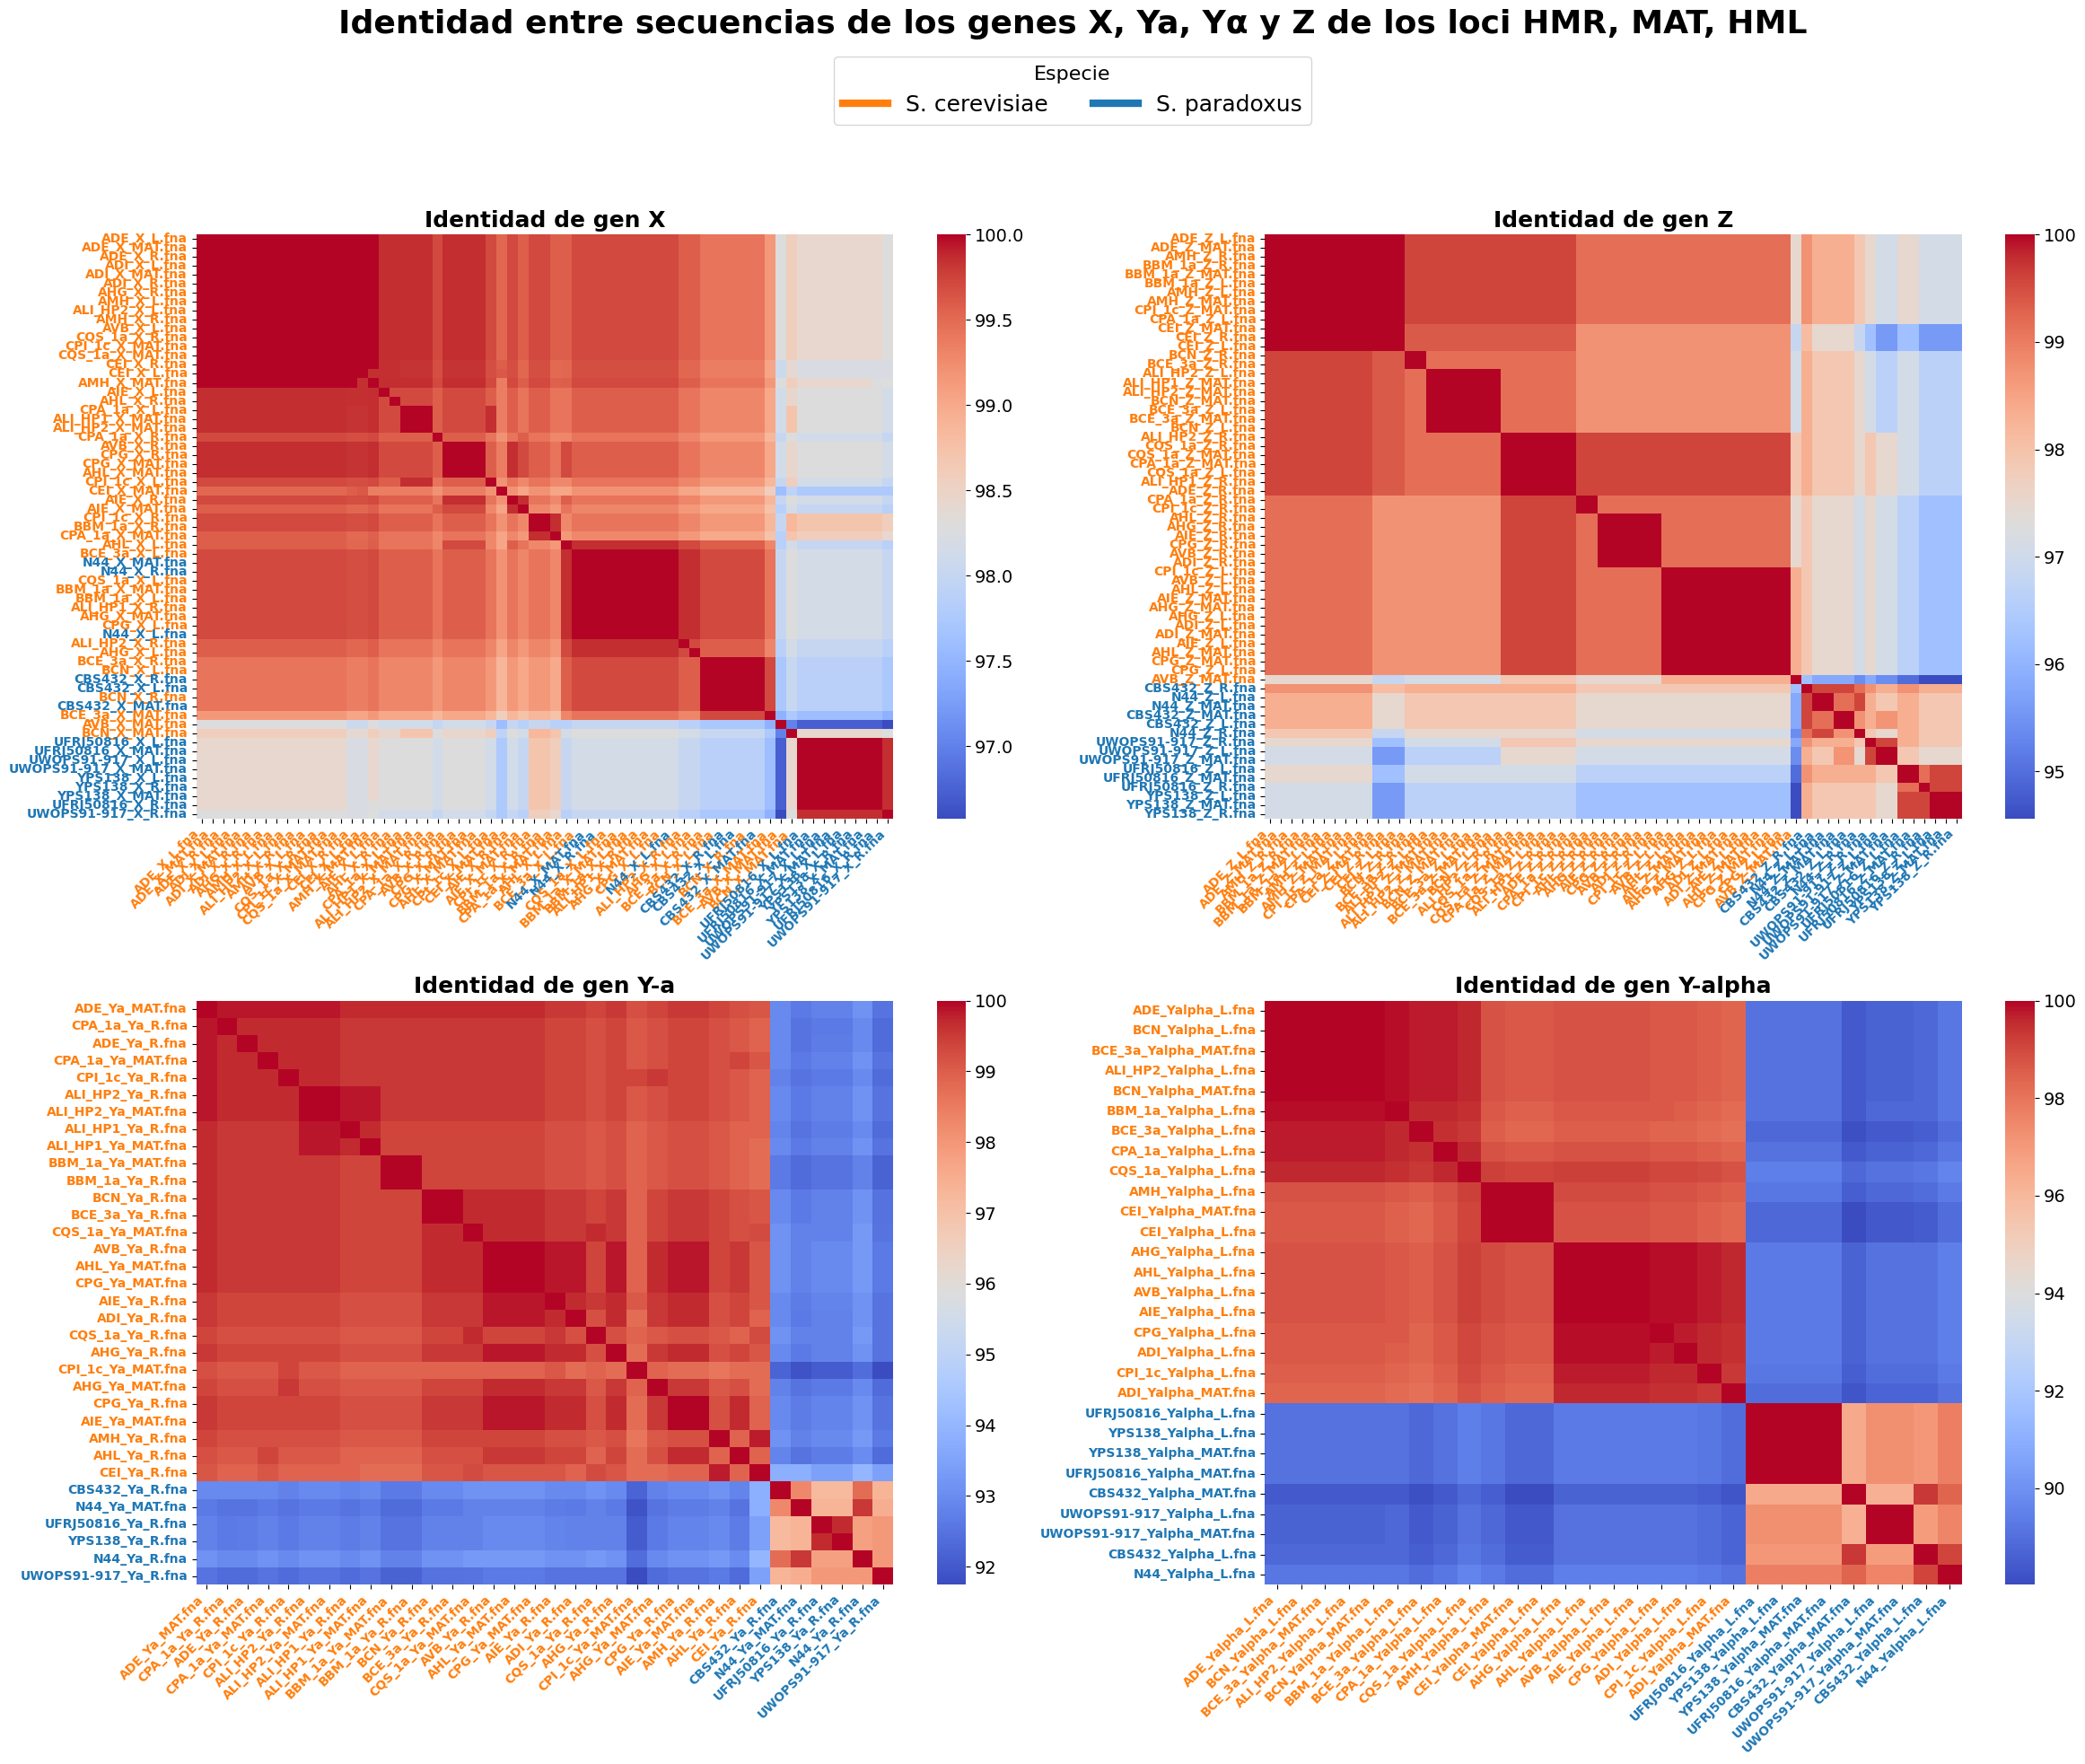

In [ ]:
generar_subplot_heatmaps('x_identidad.xlsx', 'X', 'z_identidad.xlsx', 'Z','ya_identidad.xlsx', 'Y-a', 'yalfa_identidad.xlsx', 'Y-alpha')


# **boxplots_identidad**

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, kruskal

def comparar_identidades_con_estadisticas(archivos, genes):
    os.makedirs('Images', exist_ok=True)

    n_genes = len(genes)
    fig, axes = plt.subplots(2, 2, figsize=(14, 12), sharey=True)
    axes = axes.flatten()

    todos_los_datos = {}

    for ax, archivo, gen in zip(axes, archivos, genes):
        df = obtener_matriz_ordenada(archivo)
        if df is None:
            print(f"No se pudo obtener una matriz válida para el gen {gen}.")
            continue

        datos = {'Comparación': [], 'Identidad': []}
        cepas = df.columns

        for i, cepa1 in enumerate(cepas):
            for j, cepa2 in enumerate(cepas):
                if j <= i:
                    continue

                especie1 = obtener_especie(cepa1)
                especie2 = obtener_especie(cepa2)
                identidad = df.loc[cepa1, cepa2]

                if especie1 == 'S. cerevisiae' and especie2 == 'S. cerevisiae':
                    comparacion = 'S.c vs S.c'
                elif especie1 == 'S. paradoxus' and especie2 == 'S. paradoxus':
                    comparacion = 'S.p vs S.p'
                elif (
                    (especie1 == 'S. cerevisiae' and especie2 == 'S. paradoxus') or
                    (especie1 == 'S. paradoxus' and especie2 == 'S. cerevisiae')
                ):
                    comparacion = 'S.c vs S.p'
                else:
                    comparacion = 'Otro'

                datos['Comparación'].append(comparacion)
                datos['Identidad'].append(identidad)

        df_plot = pd.DataFrame(datos)
        df_plot = df_plot[df_plot['Comparación'] != 'Otro']
        todos_los_datos[gen] = df_plot.copy()

        # Gráfico
        sns.boxplot(data=df_plot, x='Comparación', y='Identidad', palette='Set2', ax=ax)
        medias = df_plot.groupby('Comparación')['Identidad'].mean()
        desviaciones = df_plot.groupby('Comparación')['Identidad'].std()

        posiciones = range(len(medias))
        ax.errorbar(posiciones, medias, yerr=desviaciones, fmt='o', color='black', capsize=5, label='Media ± SD')
        sns.stripplot(data=df_plot, x='Comparación', y='Identidad', color='gray', alpha=0.4, jitter=True, ax=ax)

        ax.set_title(f'Identidad - gen {gen}', fontsize=14, fontweight='bold')
        ax.set_xlabel('')
        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=12)

        if ax.get_subplotspec().is_first_col():
            ax.set_ylabel('Identidad', fontsize=13)
        else:
            ax.set_ylabel('')

        ax.grid(axis='y', linestyle='--', alpha=0.5)
        if ax == axes[0]:
            ax.legend()

    fig.suptitle("Comparación de promedio de identidad en cada gen entre especies", fontsize=18, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('Images/boxplots_identidad.svg', dpi=500, bbox_inches="tight")
    plt.show()

    # Pruebas estadísticas
    print("\n--- RESULTADOS ESTADÍSTICOS ---")
    for gen, df_plot in todos_los_datos.items():
        print(f"\n▶ Gen: {gen}")

        # Prueba de normalidad por grupo
        normales = {}
        for grupo in df_plot['Comparación'].unique():
            identidades = df_plot[df_plot['Comparación'] == grupo]['Identidad']
            if len(identidades) >= 3:
                stat, p = shapiro(identidades)
                normales[grupo] = p > 0.05
                print(f"  Normalidad ({grupo}): p = {p:.4f} → {'Normal' if p > 0.05 else 'No normal'}")
            else:
                print(f"  {grupo}: pocos datos para Shapiro-Wilk")

        # Prueba de Kruskal-Wallis (no paramétrica)
        grupos = []
        nombres = []
        for grupo in ['S.c vs S.c', 'S.p vs S.p', 'S.c vs S.p']:
            identidades = df_plot[df_plot['Comparación'] == grupo]['Identidad']
            if len(identidades) > 0:
                grupos.append(identidades)
                nombres.append(grupo)

        if len(grupos) >= 2:
            stat, p = kruskal(*grupos)
            print(f"  ➤ Kruskal-Wallis entre {', '.join(nombres)}: p = {p:.4f}")
        else:
            print("  No hay suficientes grupos para comparar con Kruskal-Wallis.")

/tmp/ipython-input-2936063188.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Comparación', y='Identidad', palette='Set2', ax=ax)
/tmp/ipython-input-2936063188.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Comparación', y='Identidad', palette='Set2', ax=ax)
/tmp/ipython-input-2936063188.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Comparación', y='Identidad', palette='Set2', ax=ax)
/tmp/ipython-input-2936063188.py:54: FutureWarning: 

Passing `palette` without assigning `

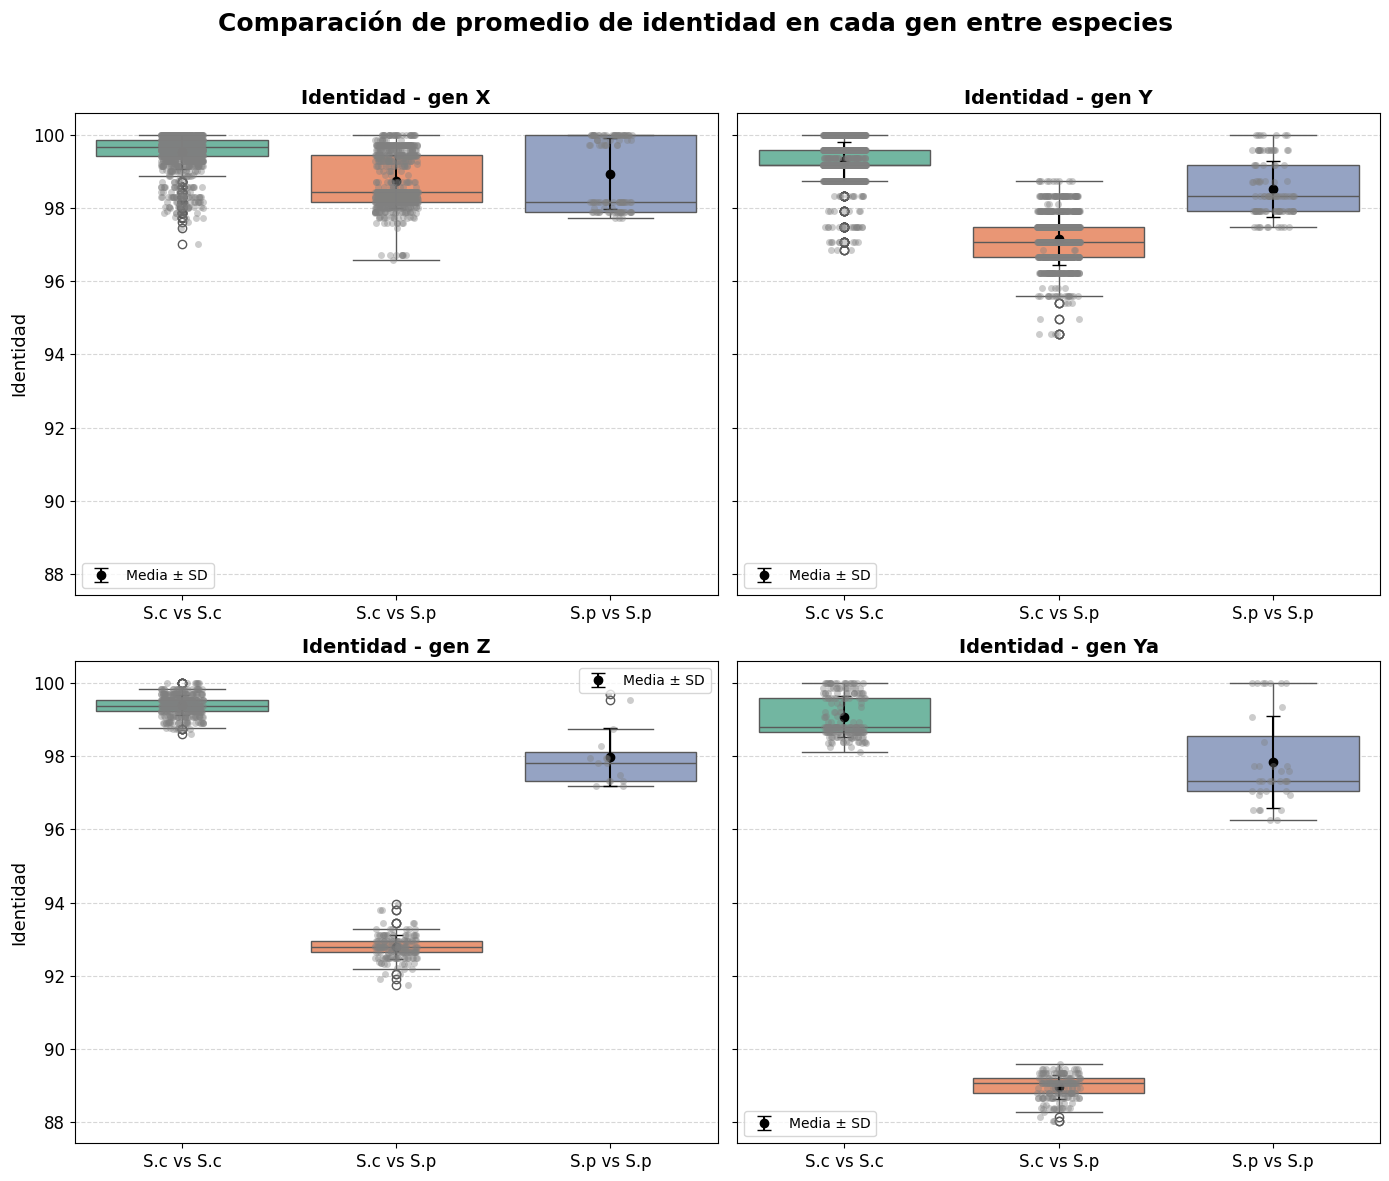


--- RESULTADOS ESTADÍSTICOS ---

▶ Gen: X
  Normalidad (S.c vs S.c): p = 0.0000 → No normal
  Normalidad (S.c vs S.p): p = 0.0000 → No normal
  Normalidad (S.p vs S.p): p = 0.0000 → No normal
  ➤ Kruskal-Wallis entre S.c vs S.c, S.p vs S.p, S.c vs S.p: p = 0.0000

▶ Gen: Y
  Normalidad (S.c vs S.c): p = 0.0000 → No normal
  Normalidad (S.c vs S.p): p = 0.0000 → No normal
  Normalidad (S.p vs S.p): p = 0.0000 → No normal
  ➤ Kruskal-Wallis entre S.c vs S.c, S.p vs S.p, S.c vs S.p: p = 0.0000

▶ Gen: Z
  Normalidad (S.c vs S.c): p = 0.0000 → No normal
  Normalidad (S.c vs S.p): p = 0.0001 → No normal
  Normalidad (S.p vs S.p): p = 0.0150 → No normal
  ➤ Kruskal-Wallis entre S.c vs S.c, S.p vs S.p, S.c vs S.p: p = 0.0000

▶ Gen: Ya
  Normalidad (S.c vs S.c): p = 0.0000 → No normal
  Normalidad (S.c vs S.p): p = 0.0000 → No normal
  Normalidad (S.p vs S.p): p = 0.0001 → No normal
  ➤ Kruskal-Wallis entre S.c vs S.c, S.p vs S.p, S.c vs S.p: p = 0.0000


In [ ]:
archivos = ['x_identidad.xlsx', 'z_identidad.xlsx', 'ya_identidad.xlsx', 'yalfa_identidad.xlsx']
genes = ['X', 'Y', 'Z', 'Ya']

comparar_identidades_con_estadisticas(archivos, genes)
